<a href="https://colab.research.google.com/github/br482-code/emulsion-tracker/blob/main/Python_for_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import scipy.optimize
import pandas as pd
import matplotlib.pyplot as plt

These libraries are imported so that we can perform mathematical and scientific operations on our data to produce graphs and find error


1.   numpy - required if any calculations need to be done
2.   scipy - required for any sort of scientific model forming
3. pandas - required to read the excel spreadsheets with data
4. matplotlib - required to plot the graphs



We have used aliases so that it is easier to operate with these libraries in the rest of the code

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


We mount the drive onto the Colab workbook so that python can now read data.xslx - the spreadsheet with the data on it

In [3]:
path = "/content/drive/MyDrive/project /data.xlsx"
df = pd.read_excel(path,sheet_name="consolidated copy")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   cylinder     182 non-null    object        
 1   formulation  182 non-null    object        
 2   iteration    182 non-null    object        
 3   y_serum      160 non-null    float64       
 4   y_top        182 non-null    int64         
 5   timestamp    182 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(1), int64(1), object(3)
memory usage: 8.7+ KB


We have used pandas to read data.xslx and check that it is what we expected from the file

In [4]:
df["y_top"] = df.groupby("cylinder")["y_top"].transform(lambda x: x.mode()[0]).astype("int64")
df.groupby("cylinder").nunique()


,formulation,iteration,y_serum,y_top,timestamp
cylinder,,,,,
C0a,1,1,9,1,13
C0b,1,1,8,1,13
E1a,1,1,12,1,13
E1b,1,1,8,1,13
E2a,1,1,11,1,13
E2b,1,1,11,1,13
E3a,1,1,12,1,13
E3b,1,1,12,1,13
X1a,1,1,8,1,13


Now we want to address the issue of error in measuring the maximum height of the column. We want one standard value for y_top so that the creaming index values are all done systematically.

First we split the 182 rows into 13 groups (for the 13 records of data)

Now we have two routes - we can either calculate the mean of each group's y_tops, or we can calculate the mode. Here, the mode is preferred as there are very few days where the y_top reading is not consistent. Using a mode means we never use a value for y_top that we haven't actually measured (as a mean would produce deciaml heights).

However, no simple function that produces a scalar exists for mode (unlike for mean) so we use the inline function lambda to overwrite for the mode.

In [5]:
df["pour_time"] = df.groupby("cylinder")["timestamp"].transform("min")
df["pour_time"].nunique()


14

We create a new column within the dataframe (df) for pour_time. We then group and select the pour times.
We then check the unique pourtimes and obtain 14 - reinforcing that we have 14 independednt cylinders

In [6]:
mask_a = df["timestamp"] == df["pour_time"]
mask_a.sum()

np.int64(14)

Using pandas we compare the timestamp column to the pour time column. This forms the mask - a series of 182 True/False values - True where a row is the cylinder's pour. We use the mask to discriminate between the two types of blank cell - ones where the value should be 0 and one's where the experiment was interrupted - specifically X3a which was disturbed so has data that should be discarded.



In [7]:
df.loc[mask_a, "y_serum"] = 0
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   cylinder     182 non-null    object        
 1   formulation  182 non-null    object        
 2   iteration    182 non-null    object        
 3   y_serum      174 non-null    float64       
 4   y_top        182 non-null    int64         
 5   timestamp    182 non-null    datetime64[ns]
 6   pour_time    182 non-null    datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(3)
memory usage: 10.1+ KB


We can see that the non-null count of y_serum has increased from 160 to 174 as 14 new values have been added - the 0s for t=0. It is still shy of the 182 as the discarded X3a data is not counted.


In [8]:
mask_b = df["cylinder"] != "X3a"
df = df[mask_b]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169 entries, 0 to 181
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   cylinder     169 non-null    object        
 1   formulation  169 non-null    object        
 2   iteration    169 non-null    object        
 3   y_serum      169 non-null    float64       
 4   y_top        169 non-null    int64         
 5   timestamp    169 non-null    datetime64[ns]
 6   pour_time    169 non-null    datetime64[ns]
dtypes: datetime64[ns](2), float64(1), int64(1), object(3)
memory usage: 10.6+ KB


Now we create a second mask - this one allows us to exclude the values from the anomalous X3a sample and results in only 169 values

In [9]:
df["elapsed"] = df["timestamp"] - df["pour_time"]
df["elapsed"] = (df["elapsed"].dt.total_seconds())/3600
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169 entries, 0 to 181
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   cylinder     169 non-null    object        
 1   formulation  169 non-null    object        
 2   iteration    169 non-null    object        
 3   y_serum      169 non-null    float64       
 4   y_top        169 non-null    int64         
 5   timestamp    169 non-null    datetime64[ns]
 6   pour_time    169 non-null    datetime64[ns]
 7   elapsed      169 non-null    float64       
dtypes: datetime64[ns](2), float64(2), int64(1), object(3)
memory usage: 11.9+ KB


This creates a new column with the elapsed times from t=0, written in hours


In [10]:
df["CI"] = (df["y_serum"])/(df["y_top"])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169 entries, 0 to 181
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   cylinder     169 non-null    object        
 1   formulation  169 non-null    object        
 2   iteration    169 non-null    object        
 3   y_serum      169 non-null    float64       
 4   y_top        169 non-null    int64         
 5   timestamp    169 non-null    datetime64[ns]
 6   pour_time    169 non-null    datetime64[ns]
 7   elapsed      169 non-null    float64       
 8   CI           169 non-null    float64       
dtypes: datetime64[ns](2), float64(3), int64(1), object(3)
memory usage: 13.2+ KB


Another column created, this time for the creaming indexes (CIs)

In [11]:
conc_map = {"C0":0, "X1":0.05, "X2": 0.1, "X3": 0.2, "E1": 0.5, "E2": 1, "E3": 2}
df["conc"] = df["formulation"].map(conc_map)

We create a dictionary for the concentrations in order to allow us to assign each different label a different concentration.

In [12]:
series_map = {"C0":"C", "X1":"X", "X2": "X", "X3": "X", "E1": "E", "E2": "E", "E3": "E"}
df["series"] = df["formulation"].map(series_map)

We do the same to map each different series to a different identifier

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169 entries, 0 to 181
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   cylinder     169 non-null    object        
 1   formulation  169 non-null    object        
 2   iteration    169 non-null    object        
 3   y_serum      169 non-null    float64       
 4   y_top        169 non-null    int64         
 5   timestamp    169 non-null    datetime64[ns]
 6   pour_time    169 non-null    datetime64[ns]
 7   elapsed      169 non-null    float64       
 8   CI           169 non-null    float64       
 9   conc         169 non-null    float64       
 10  series       169 non-null    object        
dtypes: datetime64[ns](2), float64(4), int64(1), object(4)
memory usage: 15.8+ KB


In [14]:
print(df["elapsed"].min())
print(df["elapsed"].max())
print(df["CI"].min())
print(df["CI"].max())
print(df.groupby("cylinder")["elapsed"].min())

0.0
258.98333333333335
0.0
0.543046357615894
cylinder
C0a    0.0
C0b    0.0
E1a    0.0
E1b    0.0
E2a    0.0
E2b    0.0
E3a    0.0
E3b    0.0
X1a    0.0
X1b    0.0
X2a    0.0
X2b    0.0
X3b    0.0
Name: elapsed, dtype: float64


These checks allow us to make sure that all our defined data is correct by making sure that they give results that we expect.

Now we need to check whether our formulations agree with each other, by plotting them alongside each other and observing to see if they follow similar trends

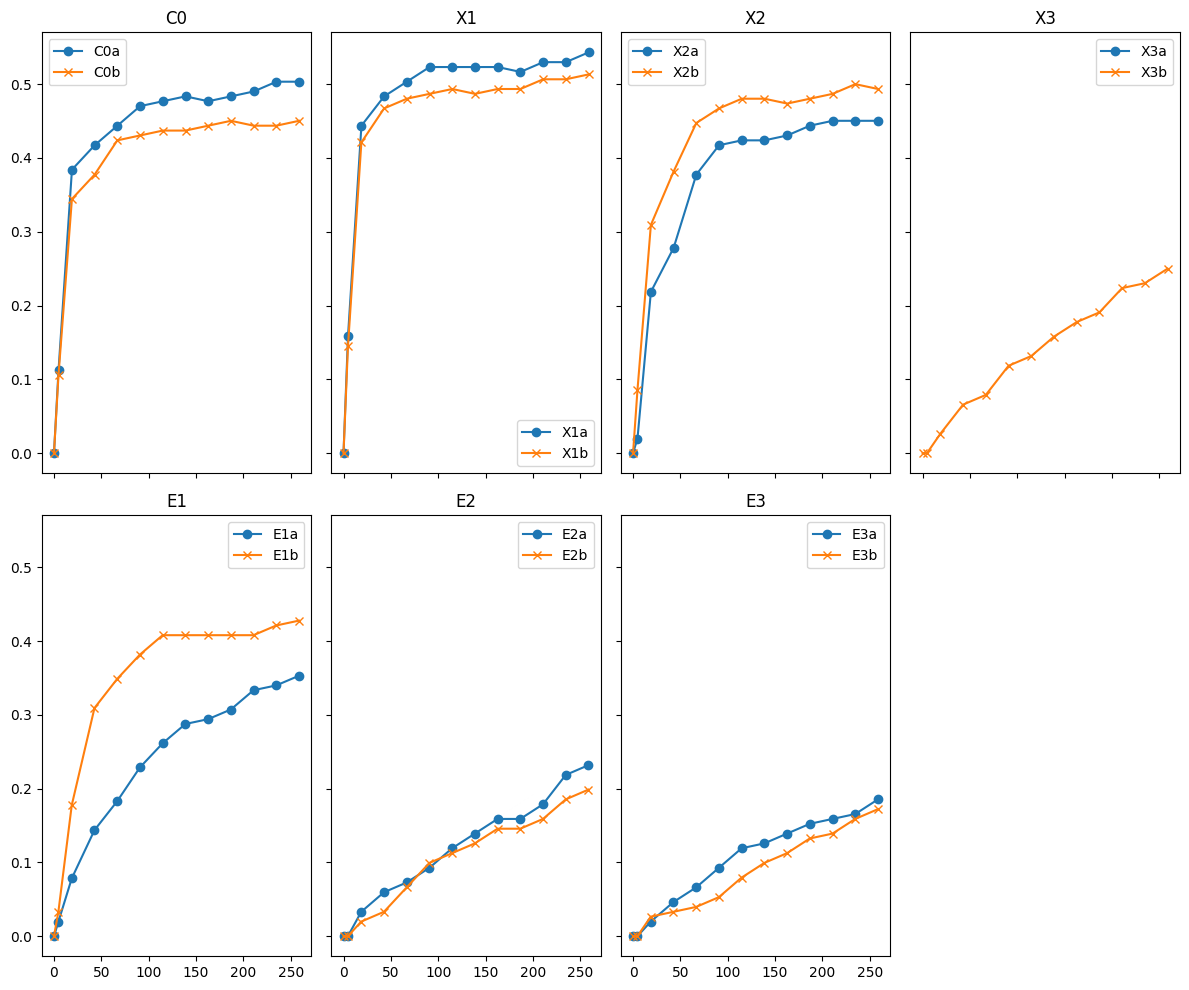

In [15]:

fig, axes = plt.subplots(nrows=2,ncols=4, sharex=True, sharey=True, figsize=(12,10))
axes_flat = axes.flatten()
for i, code in enumerate(["C0", "X1", "X2", "X3", "E1", "E2", "E3"]):
        mask_combined = (df["formulation"] == code) & (df["iteration"] == "a")
        subset = df[mask_combined]
        axes_flat[i].plot(subset["elapsed"], subset["CI"],label = code + "a" , marker = "o")

        mask_combined = (df["formulation"] == code) & (df["iteration"] == "b")
        subset = df[mask_combined]
        axes_flat[i].plot(subset["elapsed"], subset["CI"],label = code + "b" , marker = "x")

        axes_flat[i].legend()
        axes_flat[i].set_title(code)

fig.tight_layout()
axes_flat[7].set_visible(False)

We have now made use of a loop in order to repeatedly draw each graph for each sample. We have plotted both iterations on the same set of axes so we can observe what differences have arised in our investigation.

Now we plot all of the graphs on one set of axes, using colour and line style to distinguish between the different samples

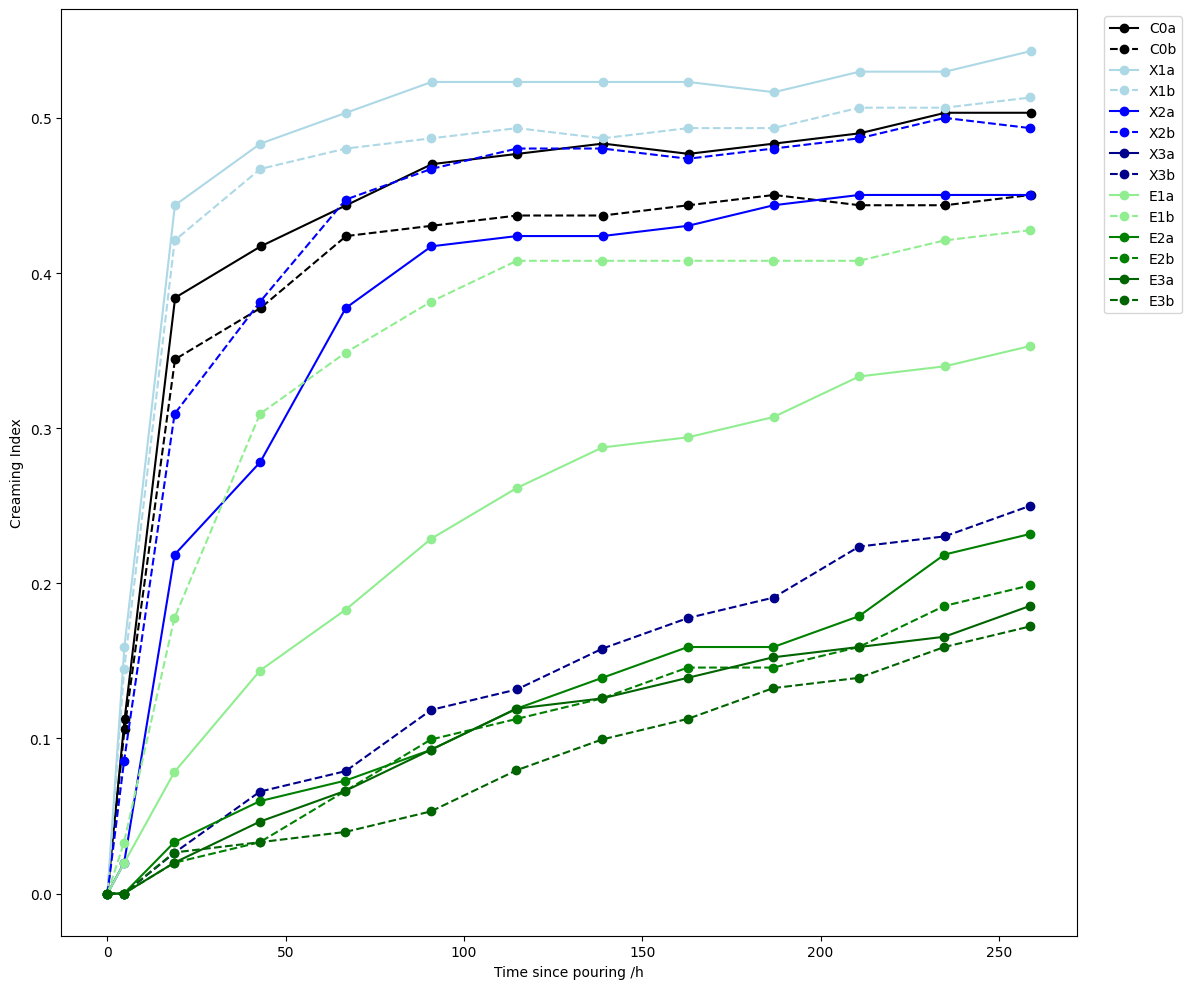

In [16]:
fig, ax = plt.subplots( figsize=(12,10))

colour_map = {"C0":"black", "X1":"lightblue", "X2":"blue", "X3":"darkblue", "E1":"lightgreen", "E2":"green", "E3":"darkgreen"}
linestyle_map = {"a":"-", "b":"--"}

for code in ["C0a", "C0b", "X1a", "X1b", "X2a", "X2b", "X3a","X3b", "E1a", "E1b", "E2a", "E2b", "E3a", "E3b"]:
        mask_combined = (df["formulation"] == code[0:2]) & (df["iteration"] == code[-1])
        subset = df[mask_combined]
        ax.plot(subset["elapsed"], subset["CI"],label = code , marker = "o", color = colour_map[code[0:2]], linestyle = linestyle_map[code[-1]])

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xlabel("Time since pouring /h")
ax.set_ylabel("Creaming Index")
fig.tight_layout()


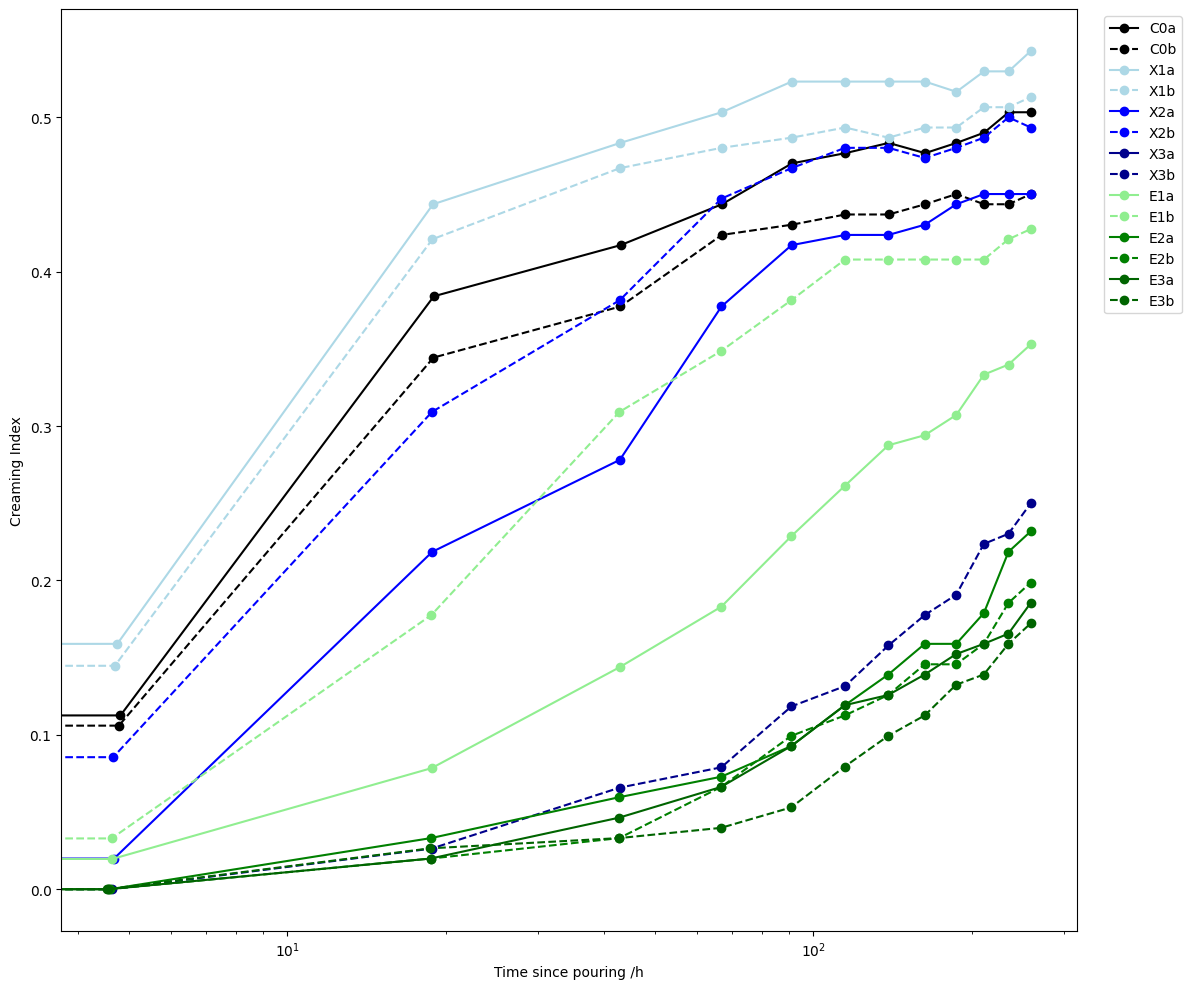

In [17]:
fig, ax = plt.subplots( figsize=(12,10))
ax.set_xscale("log")
colour_map = {"C0":"black", "X1":"lightblue", "X2":"blue", "X3":"darkblue", "E1":"lightgreen", "E2":"green", "E3":"darkgreen"}
linestyle_map = {"a":"-", "b":"--"}

for code in ["C0a", "C0b", "X1a", "X1b", "X2a", "X2b", "X3a","X3b", "E1a", "E1b", "E2a", "E2b", "E3a", "E3b"]:
        mask_combined = (df["formulation"] == code[0:2]) & (df["iteration"] == code[-1])
        subset = df[mask_combined]
        ax.plot(subset["elapsed"], subset["CI"],label = code , marker = "o", color = colour_map[code[0:2]], linestyle = linestyle_map[code[-1]])

ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xlabel("Time since pouring /h")
ax.set_ylabel("Creaming Index")
fig.tight_layout()

We have also produced a log graph, which allows us to see that not all of these lines will fit one model - the ones that plateau will fit an exponential with a free CI_max, but the ones that are still increasing at 260h cannot be fit to the same model. This is because there is no evidence for a plateau, so there will be large uncertainties or even convergence failure.

Instead, we must fix a CI_max as a fixed ceiling for every cylinder. Using this as an upper bound allows us to compare k for each fomulation

In a perfect theoretical setup, CI_max would be 0.8 (as 16mL of oil in 80mL of water) however the creaming layer is not pure oil. Using the fact that random packing of spheres is 0.64, we can see that the oil occupies 25mL as a cream layer. Thus CI_max = 0.69

In [18]:
CI_MAX = 0.69

def CI_model (t, k):
  return CI_MAX*(1-np.exp(-k*t))

print(CI_model(0,0.05))
print(CI_model(10000, 0.05))

0.0
0.69


Using CI_max we are able to develop a model and check it before we apply it to our data

We start by considering C0a, and then trying to fit a curve to it

In [19]:
mask_C0a = df["cylinder"] == "C0a"
popt, pcov = scipy.optimize.curve_fit(CI_model, df.loc[mask_C0a, "elapsed"], df.loc[mask_C0a, "CI"], p0 = [0.05])
print(popt[0])
print(np.sqrt(pcov[0,0]))

0.010133906525695452
0.0018859301033347148


We have fit a model and gotten k = 0.0101, with 19% uncertainty. This is quite a lot of uncertainty, so we must now assess whether we need to use a different model for some of the plots

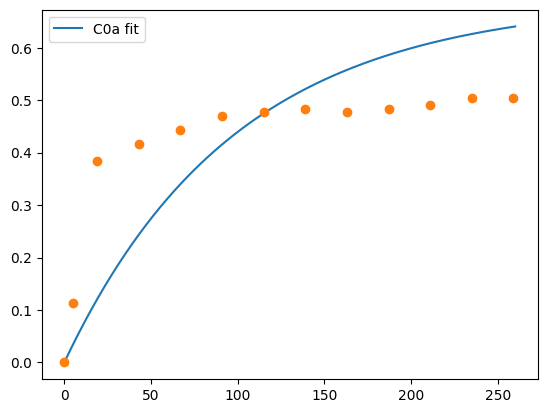

In [20]:
fig, ax = plt.subplots()
t_smooth = np.linspace(0,260,200)
ax.plot(t_smooth, CI_model(t_smooth, popt[0]), label = "C0a fit")
ax.plot(df.loc[mask_C0a, "elapsed"], df.loc[mask_C0a, "CI"], marker = "o", linestyle="none")
ax.legend()


It is clear from the figure that the model does not work as it doesn't match the data - thus we must procede with a hybrid system where CI_MAX floats for the samples which plateau but is fixed for those that do not.

In [21]:
def CI_model_free (t, k, CI_max):
  return CI_max*(1-np.exp(-k*t))

print(CI_model_free(0,0.05,0.5))
print(CI_model_free(1000,0.05,0.5))

0.0
0.5


0.0681548840322594 0.48022635445491413
0.007395781498564482 0.007355518785564755


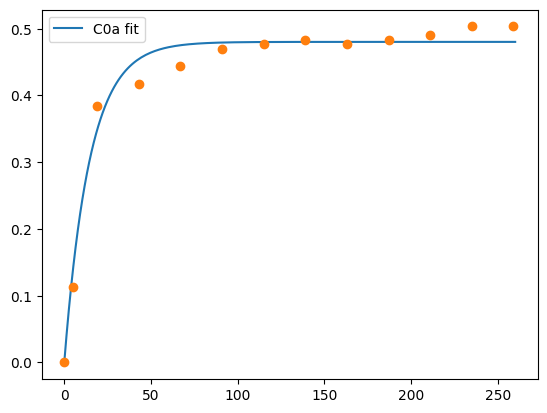

In [22]:

fig, ax = plt.subplots()
popt, pcov = scipy.optimize.curve_fit(CI_model_free, df.loc[mask_C0a, "elapsed"], df.loc[mask_C0a, "CI"], p0=[0.05, 0.5])
t_smooth = np.linspace(0,260,200)
print(popt[0], popt[1])
print(np.sqrt(pcov[0,0]), np.sqrt(pcov[1,1]))
ax.plot(t_smooth, CI_model_free(t_smooth, popt[0], popt[1]), label = "C0a fit")
ax.plot(df.loc[mask_C0a, "elapsed"], df.loc[mask_C0a, "CI"], marker = "o", linestyle="none")
ax.legend()

We have now mapped a better fit onto the points, one with an uncertainty of only 1.5%, so much better. This also produces a new result that the emulsions stopped at 0.48. This shows how the droplets packed less efficiently than predicted, causing an earlier arrest in creaming

We can now run this on all 13 formulations. We use some bound constraints to prevent the value of CI from being greater than our 0.69 maximum and from being less than our 0 minimum

In [23]:
results = []
bounds = ([0, 0], [1, 0.69])
for code in ["C0a", "C0b", "X1a", "X1b", "X2a", "X2b", "X3b", "E1a", "E1b", "E2a", "E2b", "E3a", "E3b"]:
  mask_combined = (df["formulation"] == code[0:2]) & (df["iteration"] == code[-1])
  subset = df[mask_combined]
  popt, pcov = scipy.optimize.curve_fit(CI_model_free, subset["elapsed"], subset["CI"],bounds = bounds, p0=[0.05, 0.5])
  results.append({"cylinder": code, "formulation": code[0:2], "k": popt[0], "k_err": np.sqrt(pcov[0,0]), "ci_max": popt[1], "ci_max_err": np.sqrt(pcov[1,1]), "conc":subset["conc"].iloc[0], "series": subset["series"].iloc[0]})

results_df = pd.DataFrame(results)


print(results_df)

   cylinder formulation         k     k_err    ci_max  ci_max_err  conc series
0       C0a          C0  0.068155  0.007396  0.480226    0.007355  0.00      C
1       C0b          C0  0.067399  0.005827  0.438629    0.005368  0.00      C
2       X1a          X1  0.086382  0.005996  0.522687    0.004762  0.05      X
3       X1b          X1  0.086364  0.005949  0.495354    0.004472  0.05      X
4       X2a          X2  0.027159  0.002305  0.445561    0.007977  0.10      X
5       X2b          X2  0.045343  0.003259  0.481754    0.005659  0.10      X
6       X3b          X3  0.003220  0.000458  0.438774    0.045296  0.20      X
7       E1a          E1  0.010804  0.000523  0.366948    0.006943  0.50      E
8       E1b          E1  0.029169  0.001322  0.416085    0.003822  0.50      E
9       E2a          E2  0.002430  0.000809  0.479719    0.125153  1.00      E
10      E2b          E2  0.003498  0.000764  0.324744    0.050122  1.00      E
11      E3a          E3  0.005233  0.000552  0.24296

From our results we can see that the majority of results are reasonable. However E3b had no plateau, which meant it did not follow the generic pattern of the model so produced much more uncertain results. Other notable exceptions are E2b and X3b, which both have high levels of uncertainty as they also do not plateau.

We can now plot 7 graphs and show how the model looks when drawn against the data.

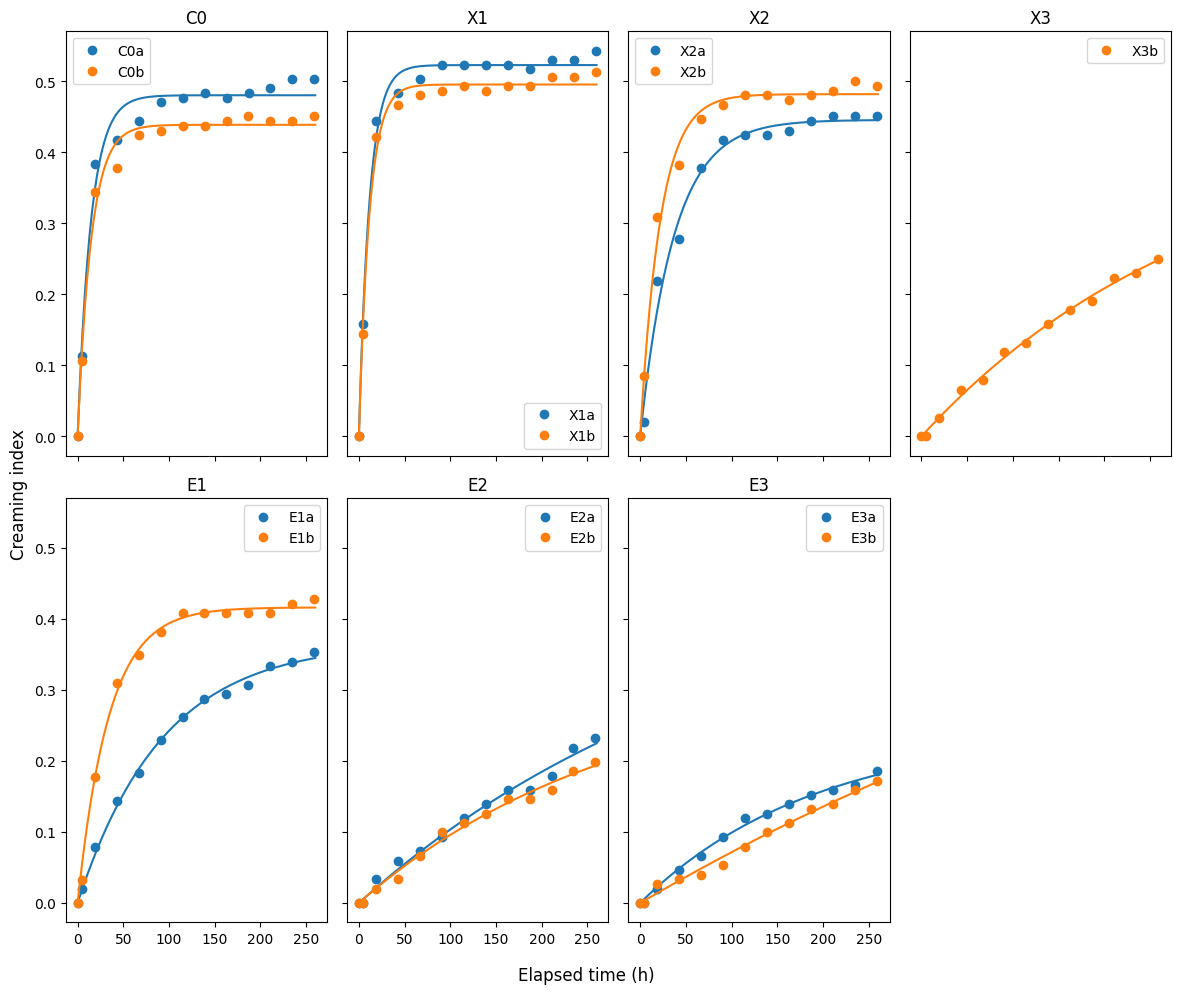

In [24]:
fig, axes = plt.subplots(nrows=2,ncols=4, sharex=True, sharey=True, figsize=(12,10))
axes_flat = axes.flatten()
fig.supxlabel("Elapsed time (h)")
fig.supylabel("Creaming index")

for i, form in enumerate(["C0", "X1", "X2", "X3", "E1", "E2", "E3"]):
        for rep in ["a", "b"]:
            code = form + rep

            mask_combined = (df["formulation"] == form) & (df["iteration"] == rep)
            subset = df[mask_combined]
            if mask_combined.sum() == 0:
                continue
            k = results_df.loc[results_df["cylinder"] == code, "k"].iloc[0]
            ci = results_df.loc[results_df["cylinder"] == code, "ci_max"].iloc[0]
            t_smooth = np.linspace(0,260,200)
            colour = "C0" if rep == "a" else "C1"
            ax = axes_flat[i]
            ax.plot(subset["elapsed"], subset["CI"], marker="o", linestyle="none", color=colour, label=code)
            ax.plot(t_smooth, CI_model_free(t_smooth, k, ci), color=colour)
        axes_flat[i].legend()
        axes_flat[i].set_title(form)

fig.tight_layout()
axes_flat[7].set_visible(False)
fig.savefig("fig_fits.png", dpi=150, bbox_inches="tight")

We have now plotted all 7 sets of formulation on axes, plotting elapsed time against CI. This allows us to see how close the models are to the data, but also how close each duplicate is to each other. This in particular highlights how E1 has some clear issues with its duplicates and how E2 and E3 did not reach the plateau points before microbial growth forced the end of the investigation

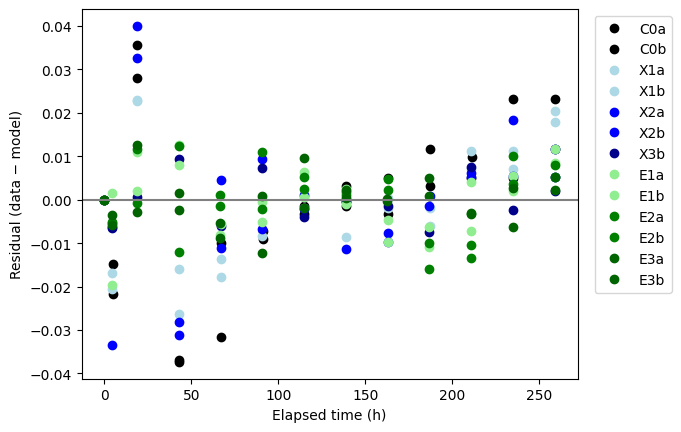

In [25]:
fig, ax = plt.subplots()
for form in (["C0", "X1", "X2", "X3", "E1", "E2", "E3"]):
        for rep in ["a", "b"]:
            code = form + rep
            mask_combined = (df["formulation"] == form) & (df["iteration"] == rep)
            subset = df[mask_combined]
            if mask_combined.sum() == 0:
                continue
            k = results_df.loc[results_df["cylinder"] == code, "k"].iloc[0]
            ci = results_df.loc[results_df["cylinder"] == code, "ci_max"].iloc[0]
            residual = subset["CI"] - CI_model_free(subset["elapsed"], k, ci)
            ax.plot(subset["elapsed"], residual, marker="o", linestyle="none", color=colour_map[form], label=code)
ax.axhline(0, color="grey")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
ax.set_xlabel("Elapsed time (h)"); ax.set_ylabel("Residual (data − model)");
fig.savefig("fig_residuals.png", dpi=150, bbox_inches="tight")

We create a scatter graph that allows us to observe the error. Given that every point sits within 0.04, we can conclude that this model is suitable. The E series values have a seemingly random distribution about the x-axis, but the C and X series have patterns.

The C series and X series both rapidly increase, decrease and then rise gradually. This shows us where our model is innacurate - it shows that the data increases faster than the exponential model at first, before then reverting and being quite close to the model for the rest of the elapsed time. The increase near the end shows that even though a plateau is modelled, there is still some minor creaming occuring.

Now we try a different approach - we want to record t_1/2 for each of the formulations. This is because this tells us the time it takes to reach half of the final CI - this gives us an alternative way of ranking the samples.

In [26]:
thalf_results = []
for form in ["C0", "X1", "X2", "X3", "E1", "E2", "E3"]:
    for rep in ["a", "b"]:
        code = form + rep
        mask_combined = (df["formulation"] == form) & (df["iteration"] == rep)
        subset = df[mask_combined]
        if mask_combined.sum() == 0:
            continue
        ci_final = subset["CI"].iloc[-1]
        t_half = np.interp(ci_final / 2, subset["CI"], subset["elapsed"])
        thalf_results.append({"cylinder": code, "ci_final": ci_final, "t_half": t_half})
thalf_df = pd.DataFrame(thalf_results)
print(thalf_df)

   cylinder  ci_final      t_half
0       C0a  0.503311   12.072764
1       C0b  0.450331   11.866667
2       X1a  0.543046   10.350774
3       X1b  0.513158   10.434126
4       X2a  0.450331   21.516667
5       X2b  0.493421   14.875000
6       X3b  0.250000  102.800000
7       E1a  0.352941   62.800000
8       E1b  0.427632   25.383333
9       E2a  0.231788  111.750000
10      E2b  0.198675   90.733333
11      E3a  0.185430   90.716667
12      E3b  0.172185  122.700000


We calculate and print the t_half data and can now merge it and compare to the model

In [27]:
results_df = results_df.merge(thalf_df, on="cylinder")
results_df["t_half_model"] = np.log(2) / results_df["k"]
print(results_df[["cylinder", "k", "t_half", "t_half_model"]])

   cylinder         k      t_half  t_half_model
0       C0a  0.068155   12.072764     10.170180
1       C0b  0.067399   11.866667     10.284239
2       X1a  0.086382   10.350774      8.024167
3       X1b  0.086364   10.434126      8.025869
4       X2a  0.027159   21.516667     25.521358
5       X2b  0.045343   14.875000     15.286729
6       X3b  0.003220  102.800000    215.290311
7       E1a  0.010804   62.800000     64.158623
8       E1b  0.029169   25.383333     23.762796
9       E2a  0.002430  111.750000    285.243334
10      E2b  0.003498   90.733333    198.171905
11      E3a  0.005233   90.716667    132.456884
12      E3b  0.001094  122.700000    633.733039


We can observe how the t_half_model values are smaller than the t_half values because the model has no delay so reaches half-height early for the plateaued cylinders. For the ones that do not plateau (X3, E2, E3) t_half_model is much longer as the model fits to a set number - CI_max = 0.69.

In [28]:
summary = results_df.groupby("formulation").agg(
    k_mean=("k", "mean"),
    k_std=("k", "std"),
    t_half_mean=("t_half", "mean"),
    t_half_std=("t_half", "std"),
    conc=("conc", "first"),
    series=("series", "first"),
).reset_index()
print(summary)

  formulation    k_mean     k_std  t_half_mean  t_half_std  conc series
0          C0  0.067777  0.000534    11.969715    0.145733  0.00      C
1          E1  0.019987  0.012987    44.091667   26.457579  0.50      E
2          E2  0.002964  0.000755   101.241667   14.861028  1.00      E
3          E3  0.003163  0.002927   106.708333   22.615632  2.00      E
4          X1  0.086373  0.000013    10.392450    0.058939  0.05      X
5          X2  0.036251  0.012858    18.195833    4.696368  0.10      X
6          X3  0.003220       NaN   102.800000         NaN  0.20      X


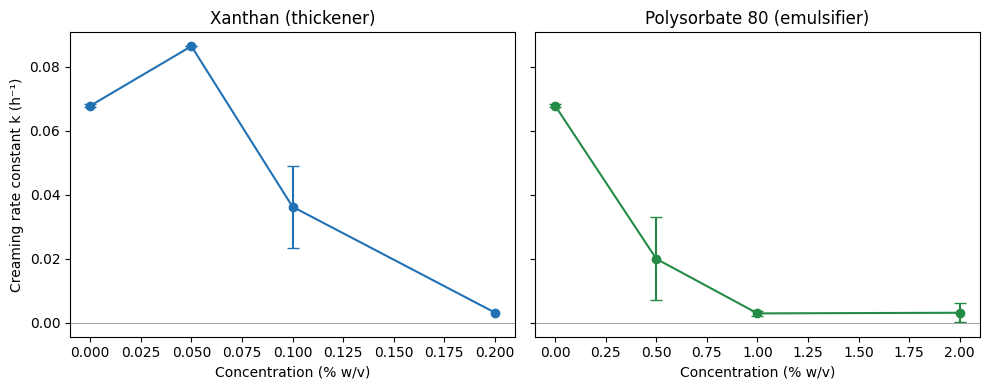

In [29]:
fig, (ax_x, ax_e) = plt.subplots(ncols=2, sharey=True, figsize=(10, 4))

for ax, s, colour in [(ax_x, "X", "#2171b5"), (ax_e, "E", "#238b45")]:
    sub = summary[(summary["series"] == s) | (summary["formulation"] == "C0")].sort_values("conc")
    ax.errorbar(sub["conc"], sub["k_mean"], yerr=sub["k_std"],
                marker="o", capsize=4, color=colour)
    ax.set_xlabel("Concentration (% w/v)")
    ax.axhline(0, color="grey", linewidth=0.5)

ax_x.set_title("Xanthan (thickener)")
ax_e.set_title("Polysorbate 80 (emulsifier)")
ax_x.set_ylabel("Creaming rate constant k (h⁻¹)")
fig.tight_layout();

We can now plot graphs of concentration against k, and then use error bars to show the uncertainty in different parts of the graph. We can use this to compare the rates of creaming when thickener or emulsifier are added:

When thickener is added, at first when 0.05% thickener is used the rate of creaming actually increases. This is due to depletion flocculation. However, after an initial increase in creaming, creaming also slows down as more thickener is added, as the rate of kinetic breakdown is slowed

When emulsifier is added, the rate of creaming decreases, showing how emulsifiers are useful for preventing kinetic breakdown.

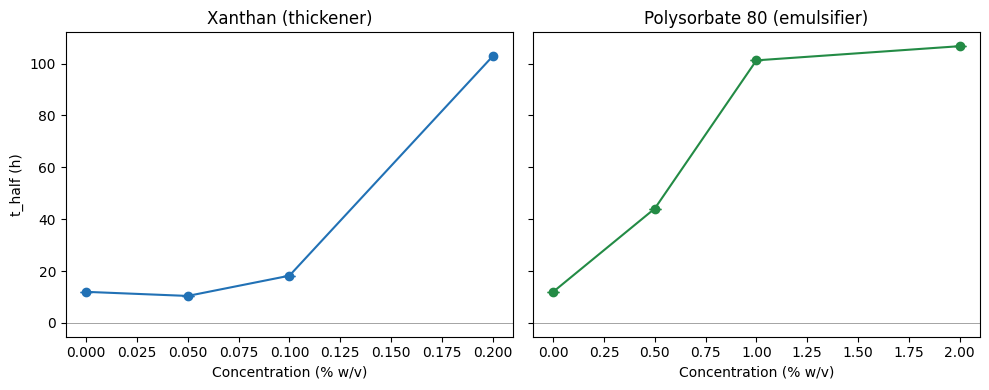

In [30]:
fig, (ax_x, ax_e) = plt.subplots(ncols=2, sharey=True, figsize=(10, 4))

for ax, s, colour in [(ax_x, "X", "#2171b5"), (ax_e, "E", "#238b45")]:
    sub = summary[(summary["series"] == s) | (summary["formulation"] == "C0")].sort_values("conc")
    ax.errorbar(sub["conc"], sub["t_half_mean"], yerr=sub["k_std"],
                marker="o", capsize=4, color=colour)
    ax.set_xlabel("Concentration (% w/v)")
    ax.axhline(0, color="grey", linewidth=0.5)

ax_x.set_title("Xanthan (thickener)")
ax_e.set_title("Polysorbate 80 (emulsifier)")
ax_x.set_ylabel("t_half (h)")
fig.tight_layout();

Now we run the same plots but with t_half instead of k. These do not rely on the model, so allow us to observe another way of seeing the same results